## IMPORTS

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.gridspec import GridSpec

In [2]:
file_path = 'D:\Projects\employee-attrition-prediction\data\WA_Fn-UseC_-HR-Employee-Attrition.csv'

In [3]:
df = pd.read_csv(file_path)

In [4]:
pd.set_option('display.max_columns', None)

In [5]:
df.head()

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,Gender,HourlyRate,JobInvolvement,JobLevel,JobRole,JobSatisfaction,MaritalStatus,MonthlyIncome,MonthlyRate,NumCompaniesWorked,Over18,OverTime,PercentSalaryHike,PerformanceRating,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,2,Female,94,3,2,Sales Executive,4,Single,5993,19479,8,Y,Yes,11,3,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,3,Male,61,2,2,Research Scientist,2,Married,5130,24907,1,Y,No,23,4,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,4,Male,92,2,1,Laboratory Technician,3,Single,2090,2396,6,Y,Yes,15,3,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,4,Female,56,3,1,Research Scientist,3,Married,2909,23159,1,Y,Yes,11,3,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,1,Male,40,3,1,Laboratory Technician,2,Married,3468,16632,9,Y,No,12,3,4,80,1,6,3,3,2,2,2,2


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Age                       1470 non-null   int64 
 1   Attrition                 1470 non-null   object
 2   BusinessTravel            1470 non-null   object
 3   DailyRate                 1470 non-null   int64 
 4   Department                1470 non-null   object
 5   DistanceFromHome          1470 non-null   int64 
 6   Education                 1470 non-null   int64 
 7   EducationField            1470 non-null   object
 8   EmployeeCount             1470 non-null   int64 
 9   EmployeeNumber            1470 non-null   int64 
 10  EnvironmentSatisfaction   1470 non-null   int64 
 11  Gender                    1470 non-null   object
 12  HourlyRate                1470 non-null   int64 
 13  JobInvolvement            1470 non-null   int64 
 14  JobLevel                

In [7]:
df.describe()

,Age,DailyRate,DistanceFromHome,Education,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,JobSatisfaction,MonthlyIncome,MonthlyRate,NumCompaniesWorked,PercentSalaryHike,PerformanceRating,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
count,1470.000000,1470.000000,1470.000000,1470.000000,1470.0,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.0,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000
mean,36.923810,802.485714,9.192517,2.912925,1.0,1024.865306,2.721769,65.891156,2.729932,2.063946,2.728571,6502.931293,14313.103401,2.693197,15.209524,3.153741,2.712245,80.0,0.793878,11.279592,2.799320,2.761224,7.008163,4.229252,2.187755,4.123129
std,9.135373,403.509100,8.106864,1.024165,0.0,602.024335,1.093082,20.329428,0.711561,1.106940,1.102846,4707.956783,7117.786044,2.498009,3.659938,0.360824,1.081209,0.0,0.852077,7.780782,1.289271,0.706476,6.126525,3.623137,3.222430,3.568136
min,18.000000,102.000000,1.000000,1.000000,1.0,1.000000,1.000000,30.000000,1.000000,1.000000,1.000000,1009.000000,2094.000000,0.000000,11.000000,3.000000,1.000000,80.0,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,30.000000,465.000000,2.000000,2.000000,1.0,491.250000,2.000000,48.000000,2.000000,1.000000,2.000000,2911.000000,8047.000000,1.000000,12.000000,3.000000,2.000000,80.0,0.000000,6.000000,2.000000,2.000000,3.000000,2.000000,0.000000,2.000000
50%,36.000000,802.000000,7.000000,3.000000,1.0,1020.500000,3.000000,66.000000,3.000000,2.000000,3.000000,4919.000000,14235.500000,2.000000,14.000000,3.000000,3.000000,80.0,1.000000,10.000000,3.000000,3.000000,5.000000,3.000000,1.000000,3.000000
75%,43.000000,1157.000000,14.000000,4.000000,1.0,1555.750000,4.000000,83.750000,3.000000,3.000000,4.000000,8379.000000,20461.500000,4.000000,18.000000,3.000000,4.000000,80.0,1.000000,15.000000,3.000000,3.000000,9.000000,7.000000,3.000000,7.000000
max,60.000000,1499.000000,29.000000,5.000000,1.0,2068.000000,4.000000,100.000000,4.000000,5.000000,4.000000,19999.000000,26999.000000,9.000000,25.000000,4.000000,4.000000,80.0,3.000000,40.000000,6.000000,4.000000,40.000000,18.000000,15.000000,17.000000


# EDA

In [8]:
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120
plt.rcParams['axes.titlesize'] = 13
plt.rcParams['axes.titleweight'] = 'bold'

df_eda = df.drop(columns=['EmployeeCount', 'EmployeeNumber', 'Over18', 'StandardHours'])

In [9]:
print(f"Shape: {df_eda.shape}")
print(f"\nMissing values:\n{df_eda.isnull().sum().sum()} total")
print(f"\nDtypes:\n{df_eda.dtypes.value_counts()}")
df_eda.describe()

Shape: (1470, 31)

Missing values:
0 total

Dtypes:
int64     23
object     8
Name: count, dtype: int64


,Age,DailyRate,DistanceFromHome,Education,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,JobSatisfaction,MonthlyIncome,MonthlyRate,NumCompaniesWorked,PercentSalaryHike,PerformanceRating,RelationshipSatisfaction,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
count,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000
mean,36.923810,802.485714,9.192517,2.912925,2.721769,65.891156,2.729932,2.063946,2.728571,6502.931293,14313.103401,2.693197,15.209524,3.153741,2.712245,0.793878,11.279592,2.799320,2.761224,7.008163,4.229252,2.187755,4.123129
std,9.135373,403.509100,8.106864,1.024165,1.093082,20.329428,0.711561,1.106940,1.102846,4707.956783,7117.786044,2.498009,3.659938,0.360824,1.081209,0.852077,7.780782,1.289271,0.706476,6.126525,3.623137,3.222430,3.568136
min,18.000000,102.000000,1.000000,1.000000,1.000000,30.000000,1.000000,1.000000,1.000000,1009.000000,2094.000000,0.000000,11.000000,3.000000,1.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,30.000000,465.000000,2.000000,2.000000,2.000000,48.000000,2.000000,1.000000,2.000000,2911.000000,8047.000000,1.000000,12.000000,3.000000,2.000000,0.000000,6.000000,2.000000,2.000000,3.000000,2.000000,0.000000,2.000000
50%,36.000000,802.000000,7.000000,3.000000,3.000000,66.000000,3.000000,2.000000,3.000000,4919.000000,14235.500000,2.000000,14.000000,3.000000,3.000000,1.000000,10.000000,3.000000,3.000000,5.000000,3.000000,1.000000,3.000000
75%,43.000000,1157.000000,14.000000,4.000000,4.000000,83.750000,3.000000,3.000000,4.000000,8379.000000,20461.500000,4.000000,18.000000,3.000000,4.000000,1.000000,15.000000,3.000000,3.000000,9.000000,7.000000,3.000000,7.000000
max,60.000000,1499.000000,29.000000,5.000000,4.000000,100.000000,4.000000,5.000000,4.000000,19999.000000,26999.000000,9.000000,25.000000,4.000000,4.000000,3.000000,40.000000,6.000000,4.000000,40.000000,18.000000,15.000000,17.000000


### Target Distribution (Class Imbalance)

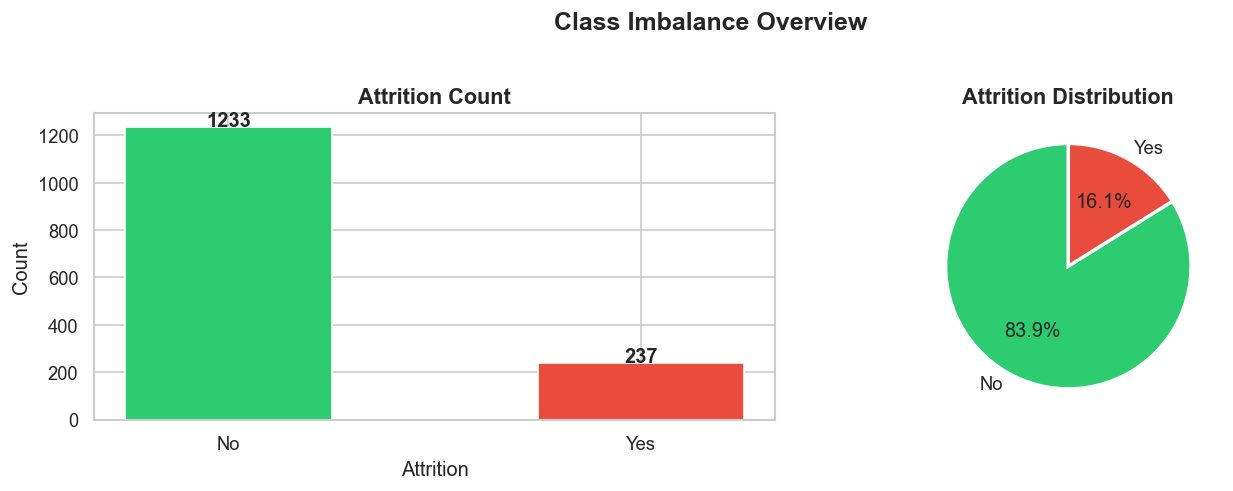

Attrition Rate: 16.1%


In [42]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Count plot
counts = df_eda['Attrition'].value_counts()
colors = ['#2ecc71', '#e74c3c']
axes[0].bar(counts.index, counts.values, color=colors, edgecolor='white', width=0.5)
axes[0].set_title('Attrition Count')
axes[0].set_xlabel('Attrition')
axes[0].set_ylabel('Count')
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 5, str(v), ha='center', fontweight='bold')

# Pie chart
axes[1].pie(counts.values, labels=counts.index, autopct='%1.1f%%',
            colors=colors, startangle=90, wedgeprops={'edgecolor': 'white', 'linewidth': 2})
axes[1].set_title('Attrition Distribution')

plt.suptitle('Class Imbalance Overview', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../assets/plots/01_class_imbalance.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Attrition Rate: {counts['Yes']/len(df_eda)*100:.1f}%")

The dataset is heavily imbalanced — only ~16% of employees left the company.
This means accuracy alone is a misleading metric, and techniques like SMOTE
are necessary to prevent the model from simply predicting "No" for everyone.

### Attrition Rate by Key Categorical Features

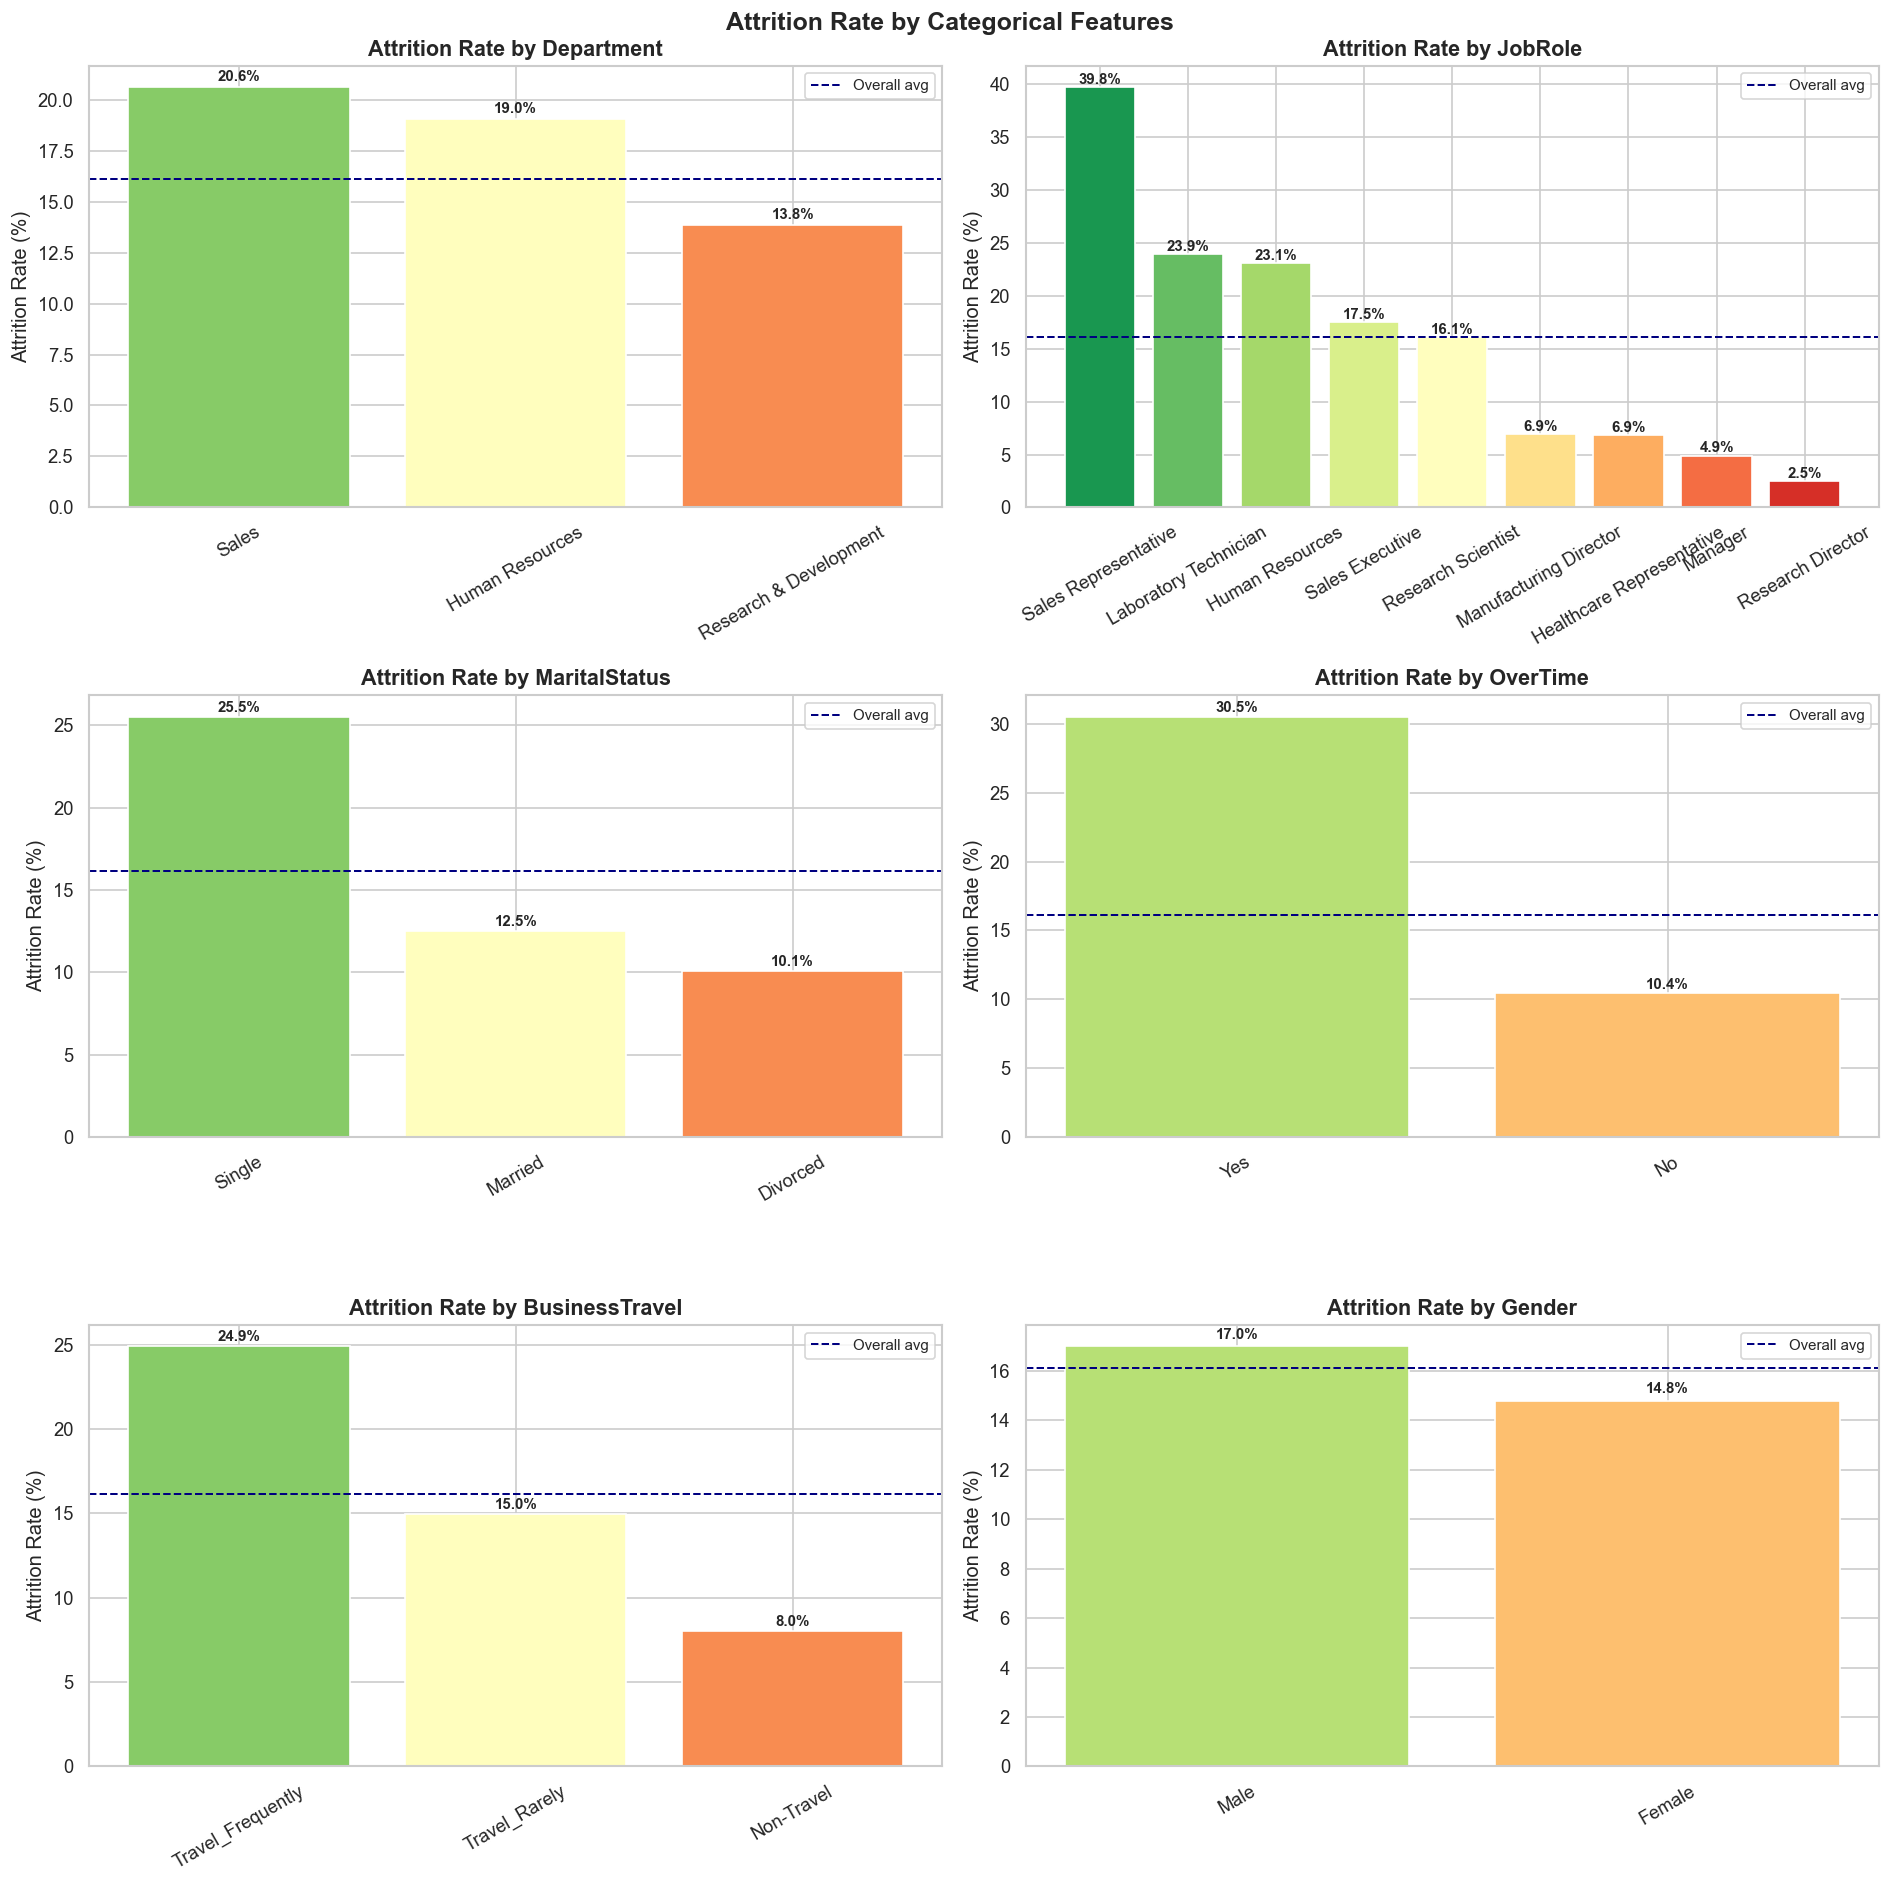

In [43]:
cat_cols = ['Department', 'JobRole', 'MaritalStatus', 'OverTime', 'BusinessTravel', 'Gender']

fig, axes = plt.subplots(3, 2, figsize=(16, 16))
axes = axes.flatten()

for i, col in enumerate(cat_cols):
    attrition_rate = df_eda.groupby(col)['Attrition'].apply(
        lambda x: (x == 'Yes').sum() / len(x) * 100
    ).sort_values(ascending=False)

    bars = axes[i].bar(attrition_rate.index, attrition_rate.values,
                        color=sns.color_palette('RdYlGn_r', len(attrition_rate)),
                        edgecolor='white')
    axes[i].set_title(f'Attrition Rate by {col}')
    axes[i].set_ylabel('Attrition Rate (%)')
    axes[i].set_xlabel('')
    axes[i].tick_params(axis='x', rotation=30)
    axes[i].axhline(y=df_eda['Attrition'].value_counts(normalize=True)['Yes']*100,
                    color='navy', linestyle='--', linewidth=1.2, label='Overall avg')
    axes[i].legend(fontsize=9)

    for bar, val in zip(bars, attrition_rate.values):
        axes[i].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                     f'{val:.1f}%', ha='center', fontsize=9, fontweight='bold')

plt.suptitle('Attrition Rate by Categorical Features', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('../assets/plots/02_attrition_by_categorical.png', dpi=150, bbox_inches='tight')
plt.show()

Key observations:
- OverTime is the strongest categorical predictor — employees working overtime
  leave at nearly 3x the rate of those who don't
- Sales Representatives and Human Resources roles have the highest attrition rates
- Single employees leave significantly more than married or divorced ones
- Employees who travel frequently have higher attrition than non-travelers
- Gender shows minimal difference in attrition rates

### Attrition vs Numerical Features (KDE plots)

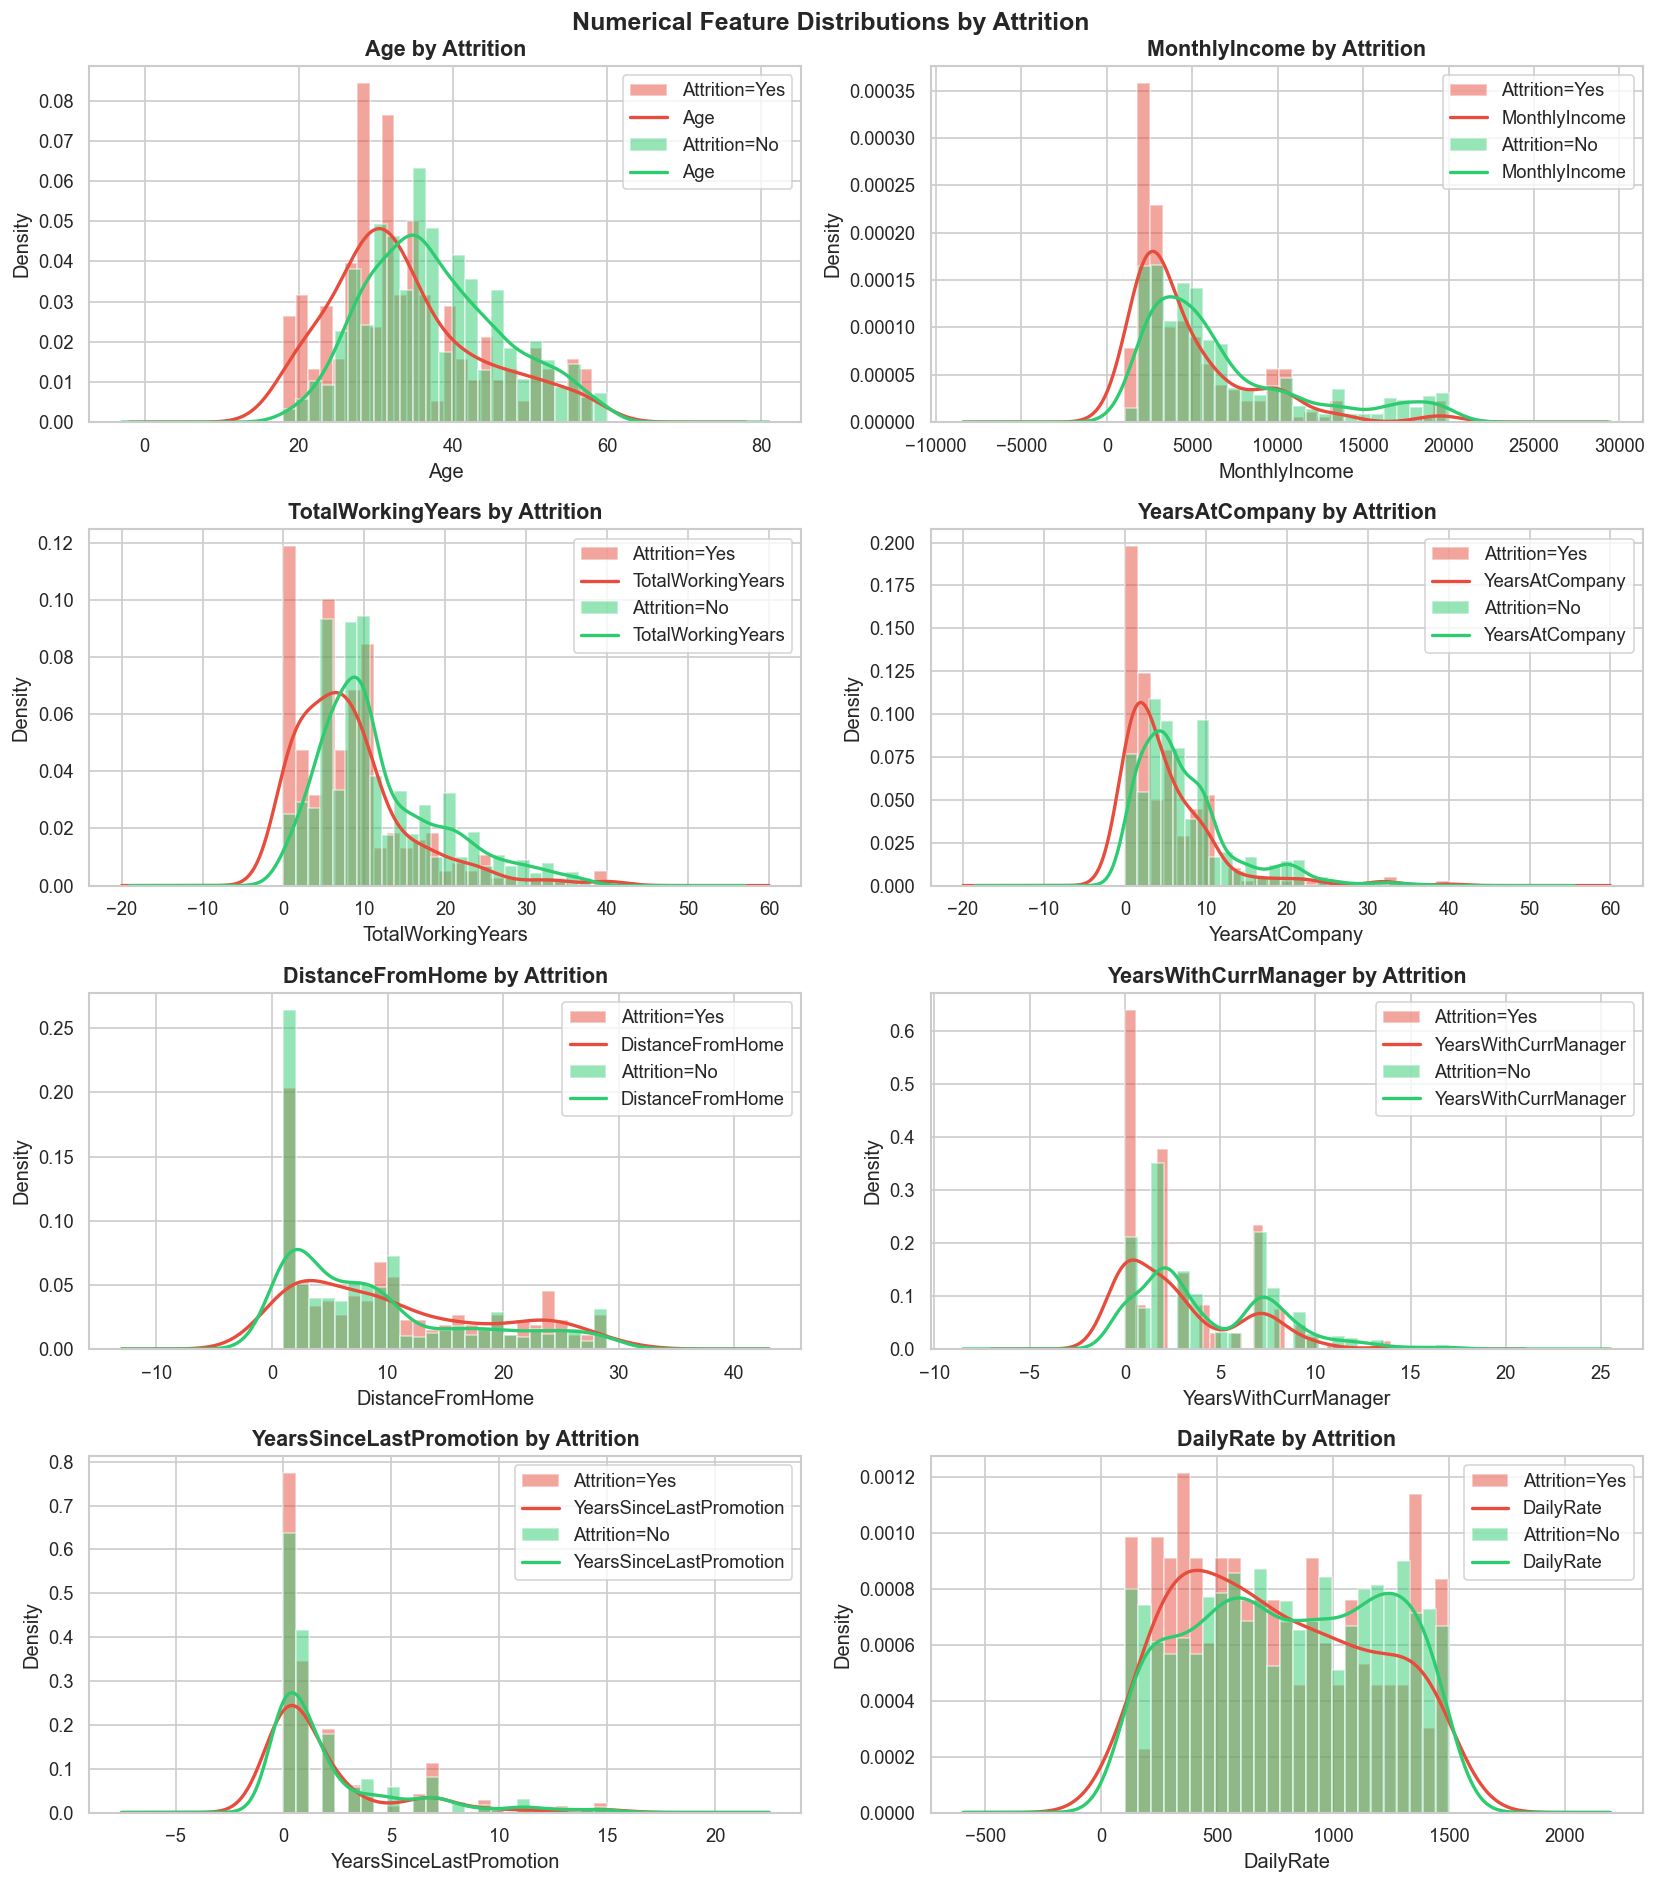

In [44]:
num_cols = ['Age', 'MonthlyIncome', 'TotalWorkingYears', 'YearsAtCompany',
            'DistanceFromHome', 'YearsWithCurrManager', 'YearsSinceLastPromotion', 'DailyRate']

fig, axes = plt.subplots(4, 2, figsize=(14, 16))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    for label, color in zip(['Yes', 'No'], ['#e74c3c', '#2ecc71']):
        axes[i].hist(df_eda[df_eda['Attrition'] == label][col],
                     bins=25, alpha=0.5, color=color, label=f'Attrition={label}',
                     density=True, edgecolor='white')
        df_eda[df_eda['Attrition'] == label][col].plot.kde(ax=axes[i], color=color, linewidth=2)
    axes[i].set_title(f'{col} by Attrition')
    axes[i].set_xlabel(col)
    axes[i].legend()

plt.suptitle('Numerical Feature Distributions by Attrition', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('../assets/plots/03_numerical_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

Key observations:
- Younger employees (20-30) show significantly higher attrition
- Lower MonthlyIncome strongly correlates with attrition — employees earning
  less are far more likely to leave
- Employees with fewer TotalWorkingYears and YearsAtCompany tend to leave more,
  suggesting early-career employees are at highest risk
- DistanceFromHome shows a slight positive relationship with attrition

### Ordinal Features vs Attrition (Stacked Bar)

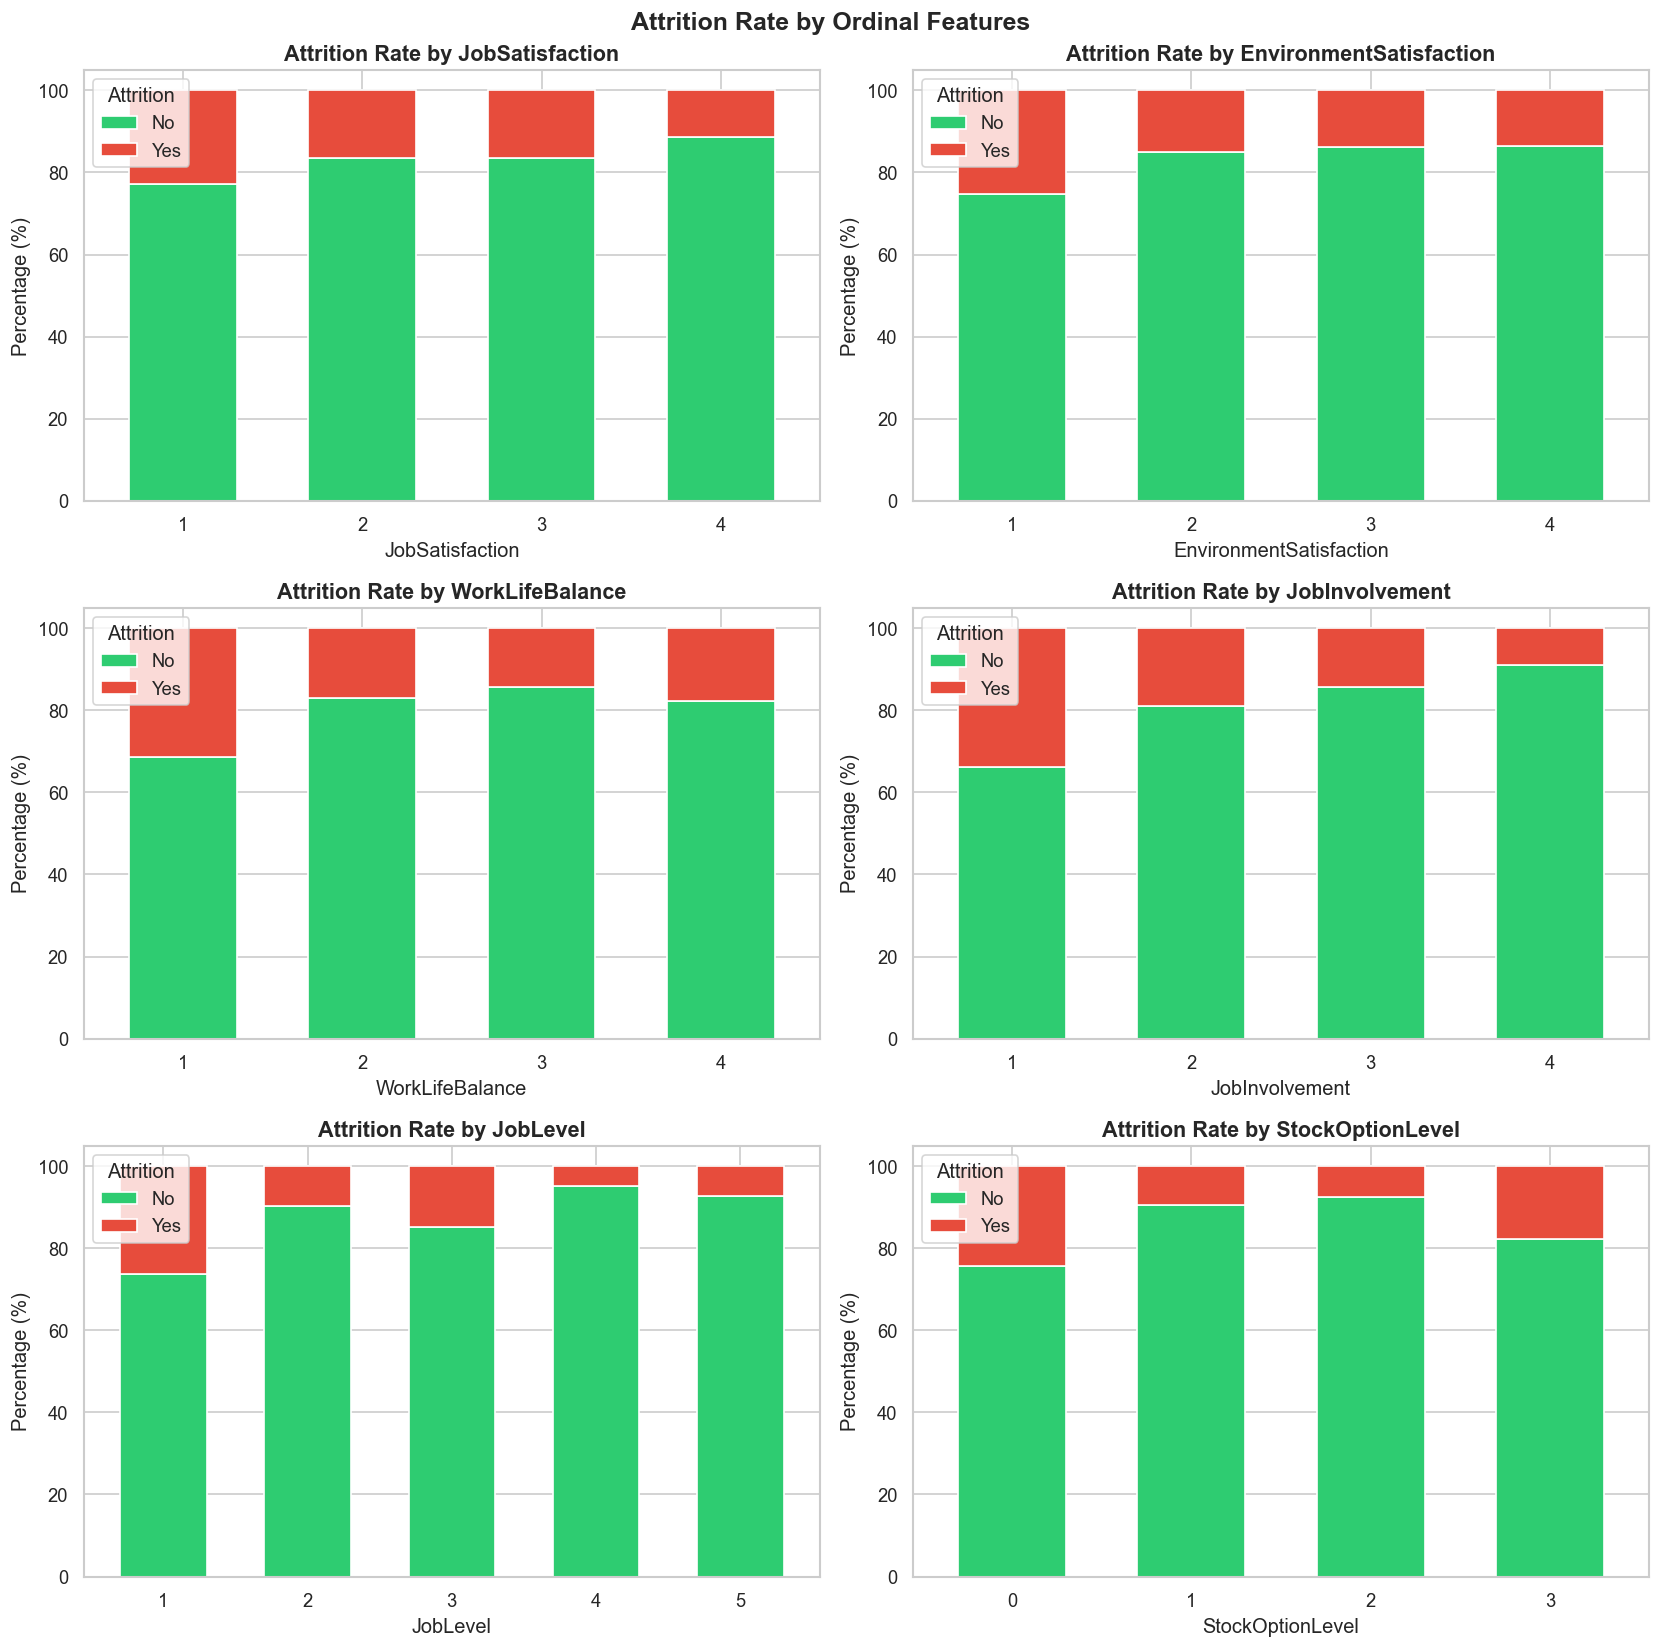

In [45]:
ordinal_cols = ['JobSatisfaction', 'EnvironmentSatisfaction', 'WorkLifeBalance',
                'JobInvolvement', 'JobLevel', 'StockOptionLevel']

fig, axes = plt.subplots(3, 2, figsize=(14, 14))
axes = axes.flatten()

for i, col in enumerate(ordinal_cols):
    ct = pd.crosstab(df_eda[col], df_eda['Attrition'], normalize='index') * 100
    ct.plot(kind='bar', stacked=True, ax=axes[i],
            color=['#2ecc71', '#e74c3c'], edgecolor='white', width=0.6)
    axes[i].set_title(f'Attrition Rate by {col}')
    axes[i].set_ylabel('Percentage (%)')
    axes[i].set_xlabel(col)
    axes[i].tick_params(axis='x', rotation=0)
    axes[i].legend(['No', 'Yes'], title='Attrition')

plt.suptitle('Attrition Rate by Ordinal Features', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('../assets/plots/04_ordinal_features.png', dpi=150, bbox_inches='tight')
plt.show()

Key observations:
- Low JobSatisfaction (level 1) has the highest attrition rate
- Low EnvironmentSatisfaction strongly predicts attrition
- Poor WorkLifeBalance (level 1) leads to significantly higher attrition
- Low JobInvolvement employees are more likely to leave
- JobLevel 1 (entry level) has the highest attrition — senior employees are
  more stable
- StockOptionLevel 0 employees leave the most, suggesting equity compensation
  is a retention factor

### Correlation Heatmap

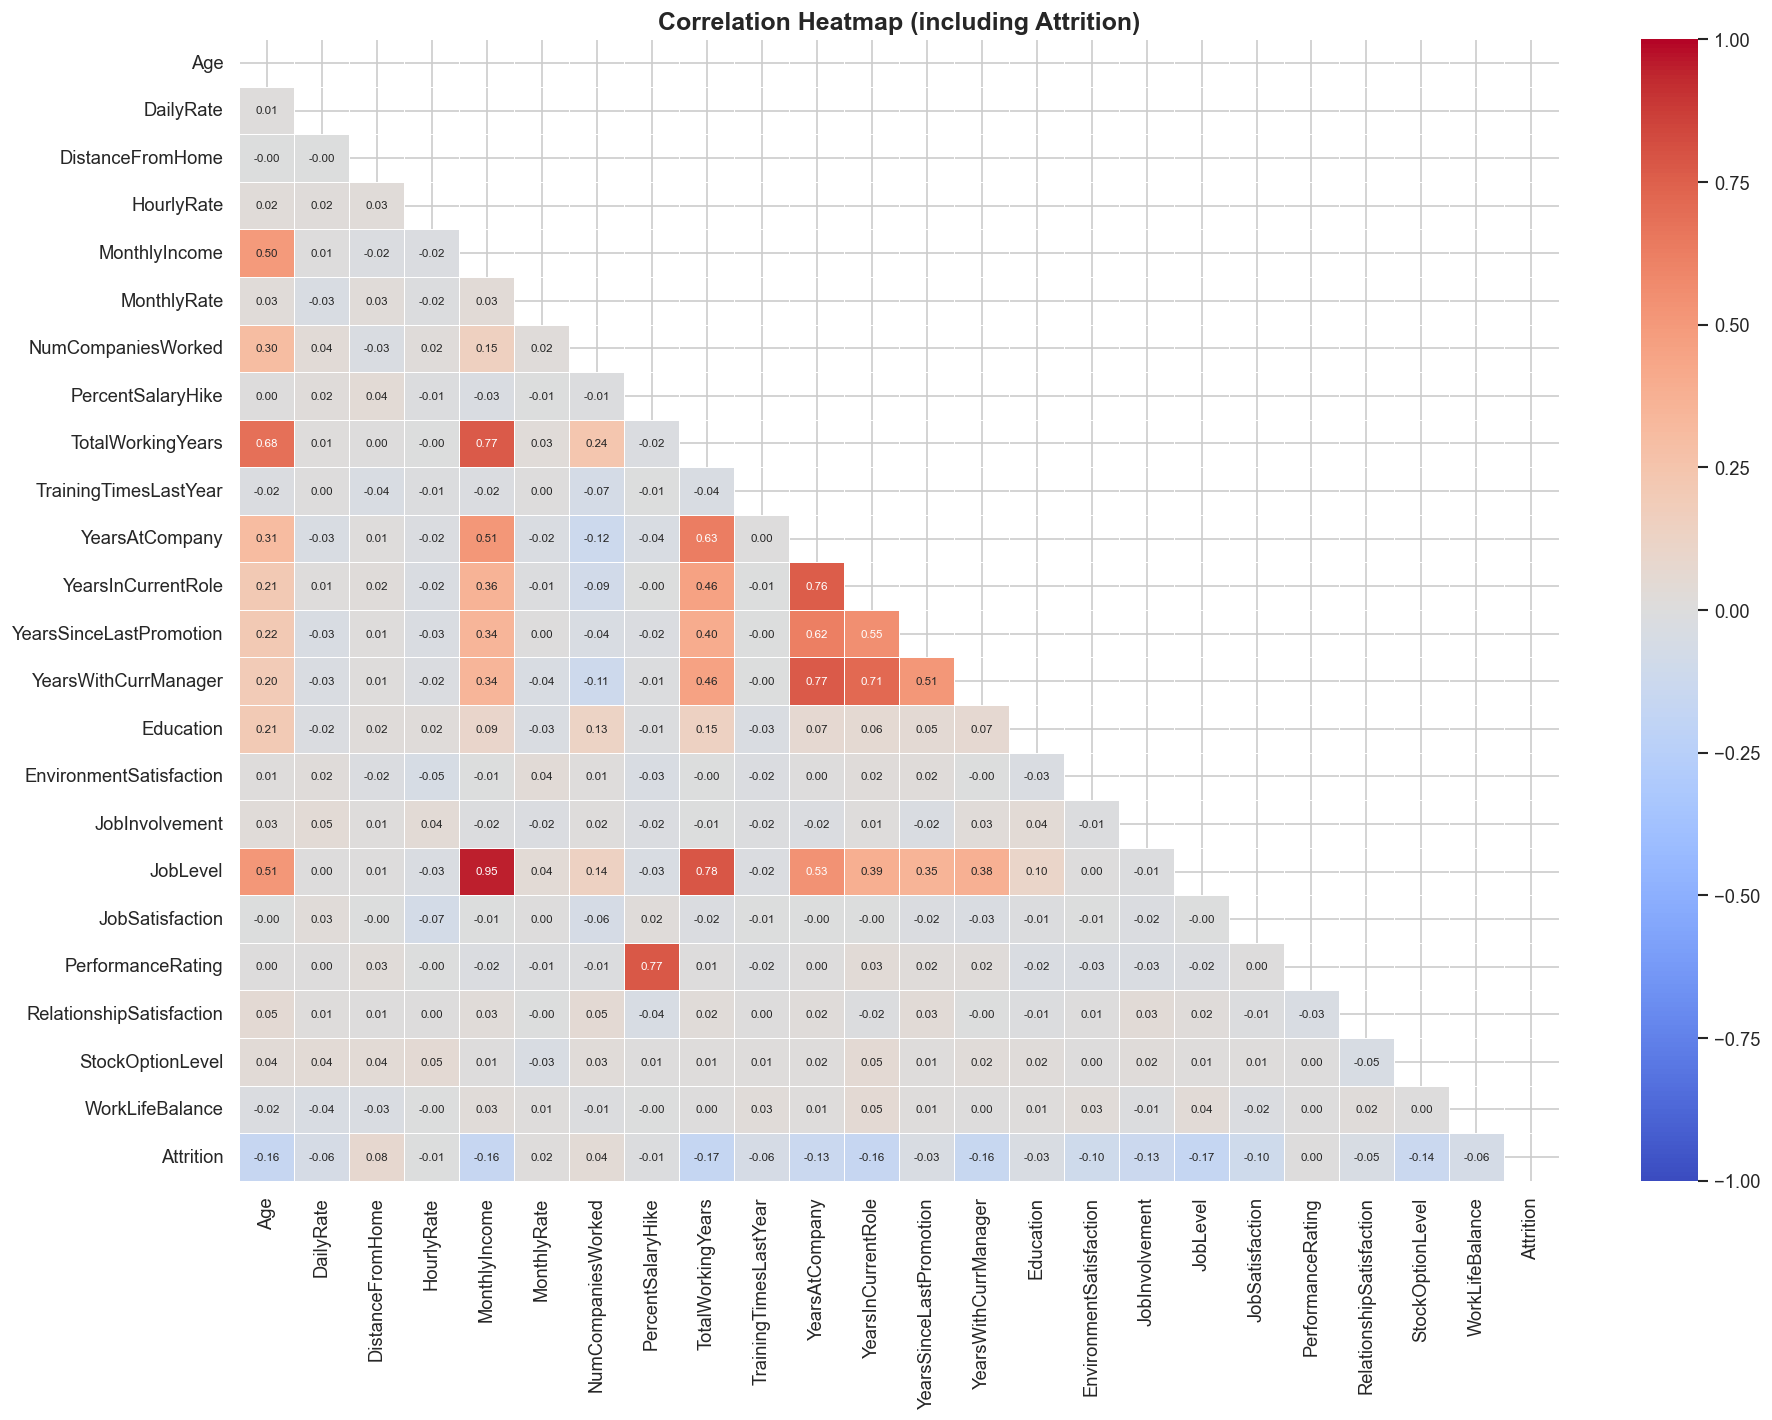

In [46]:
numerical_ordinal = ['Education', 'EnvironmentSatisfaction', 'JobInvolvement',
                     'JobLevel', 'JobSatisfaction', 'PerformanceRating',
                     'RelationshipSatisfaction', 'StockOptionLevel', 'WorkLifeBalance']

numerical_continuous = ['Age', 'DailyRate', 'DistanceFromHome', 'HourlyRate',
                        'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked',
                        'PercentSalaryHike', 'TotalWorkingYears', 'TrainingTimesLastYear',
                        'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion',
                        'YearsWithCurrManager']

all_num = numerical_continuous + numerical_ordinal
df_corr = df_eda[all_num].copy()
df_corr['Attrition'] = (df_eda['Attrition'] == 'Yes').astype(int)

corr_matrix = df_corr.corr()

fig, ax = plt.subplots(figsize=(16, 12))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, ax=ax, linewidths=0.5, annot_kws={'size': 7},
            vmin=-1, vmax=1)
ax.set_title('Correlation Heatmap (including Attrition)', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('../assets/plots/05_correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

Strong multicollinearity exists between experience-related features —
TotalWorkingYears, YearsAtCompany, YearsInCurrentRole, and YearsWithCurrManager
are all highly correlated with each other and with MonthlyIncome. This makes
sense as seniority drives salary. These won't be dropped since tree-based models
handle multicollinearity well, and we're not doing linear regression.

### Top Features Correlated with Attrition

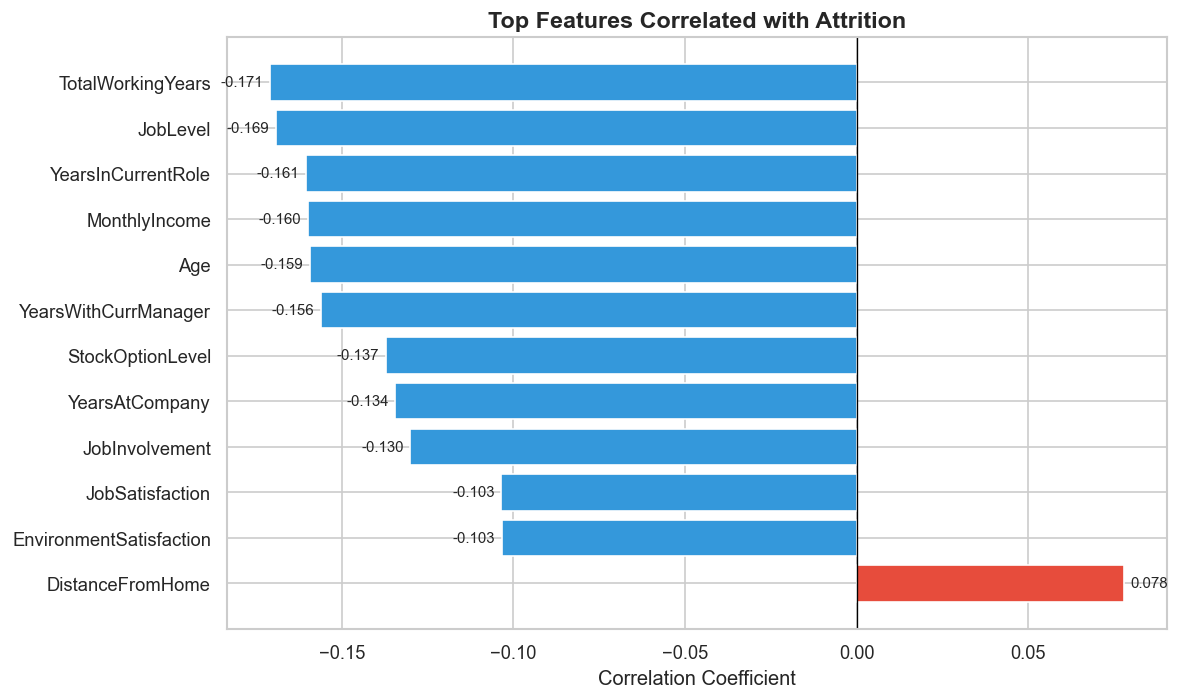

In [47]:
attrition_corr = corr_matrix['Attrition'].drop('Attrition').sort_values(key=abs, ascending=False).head(12)

colors = ['#e74c3c' if v > 0 else '#3498db' for v in attrition_corr.values]

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.barh(attrition_corr.index[::-1], attrition_corr.values[::-1], color=colors[::-1], edgecolor='white')
ax.axvline(x=0, color='black', linewidth=0.8)
ax.set_title('Top Features Correlated with Attrition', fontsize=14, fontweight='bold')
ax.set_xlabel('Correlation Coefficient')

for bar, val in zip(bars, attrition_corr.values[::-1]):
    ax.text(val + (0.002 if val >= 0 else -0.002), bar.get_y() + bar.get_height()/2,
            f'{val:.3f}', va='center', ha='left' if val >= 0 else 'right', fontsize=9)

plt.tight_layout()
plt.savefig('../assets/plots/06_top_correlations.png', dpi=150, bbox_inches='tight')
plt.show()

JobLevel, MonthlyIncome and TotalWorkingYears are the most negatively correlated
with attrition — higher seniority and pay = better retention. OverTime (encoded)
is the strongest positive predictor, confirming the earlier categorical analysis.
These insights directly guided our feature engineering decisions.

### Age & Income Deep Dive

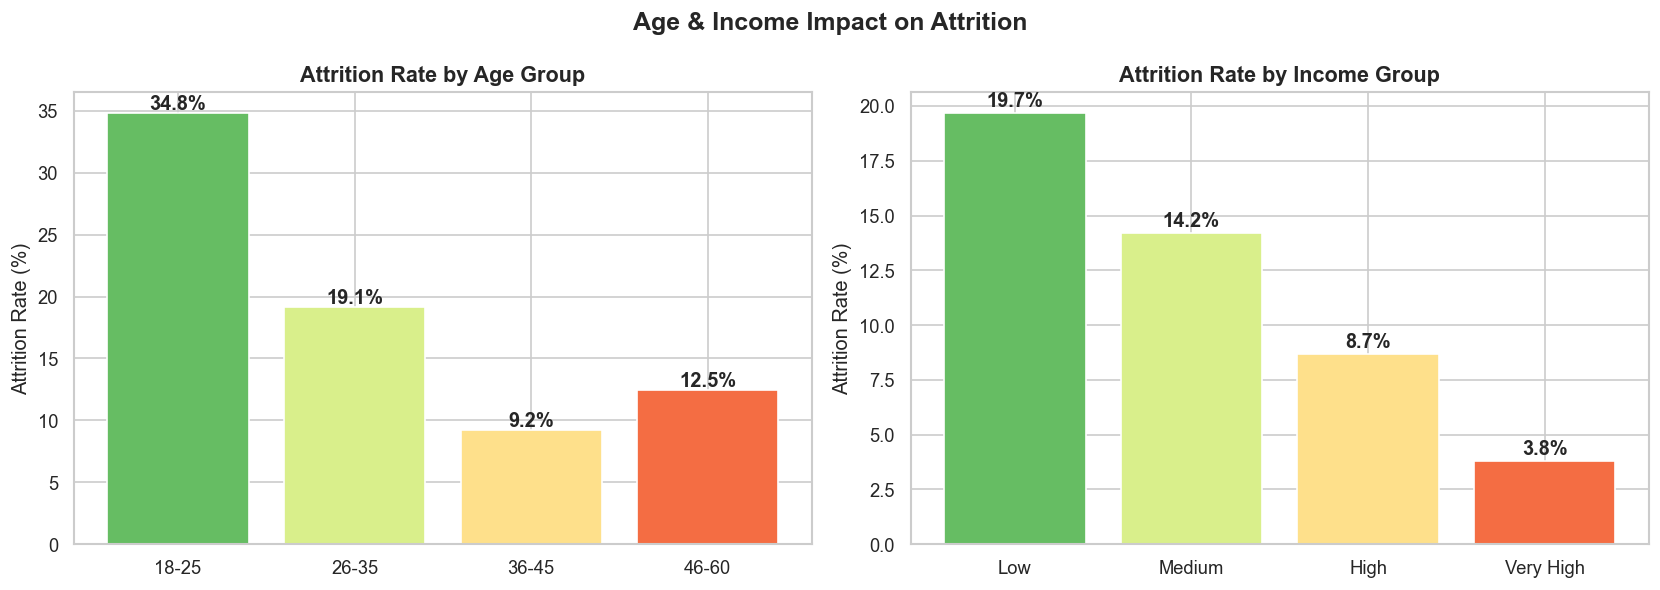

In [48]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Age bins
df_eda['AgeGroup'] = pd.cut(df_eda['Age'], bins=[18, 25, 35, 45, 60],
                             labels=['18-25', '26-35', '36-45', '46-60'])
age_attr = df_eda.groupby('AgeGroup', observed=True)['Attrition'].apply(
    lambda x: (x == 'Yes').sum() / len(x) * 100)
bars = axes[0].bar(age_attr.index, age_attr.values,
                   color=sns.color_palette('RdYlGn_r', 4), edgecolor='white')
axes[0].set_title('Attrition Rate by Age Group')
axes[0].set_ylabel('Attrition Rate (%)')
for bar, val in zip(bars, age_attr.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                 f'{val:.1f}%', ha='center', fontweight='bold')

# Income bins
df_eda['IncomeGroup'] = pd.cut(df_eda['MonthlyIncome'], bins=4,
                                labels=['Low', 'Medium', 'High', 'Very High'])
inc_attr = df_eda.groupby('IncomeGroup', observed=True)['Attrition'].apply(
    lambda x: (x == 'Yes').sum() / len(x) * 100)
bars2 = axes[1].bar(inc_attr.index, inc_attr.values,
                    color=sns.color_palette('RdYlGn_r', 4), edgecolor='white')
axes[1].set_title('Attrition Rate by Income Group')
axes[1].set_ylabel('Attrition Rate (%)')
for bar, val in zip(bars2, inc_attr.values):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                 f'{val:.1f}%', ha='center', fontweight='bold')

plt.suptitle('Age & Income Impact on Attrition', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('../assets/plots/07_age_income_deepdive.png', dpi=150, bbox_inches='tight')
plt.show()

df_eda.drop(columns=['AgeGroup', 'IncomeGroup'], inplace=True)

The 18-25 age group has by far the highest attrition rate, likely due to
early career exploration and fewer financial commitments. Attrition drops
consistently as income increases — the lowest income group leaves at nearly
3-4x the rate of the highest income group, making compensation a critical
retention lever.

### Overtime and Department Heatmap

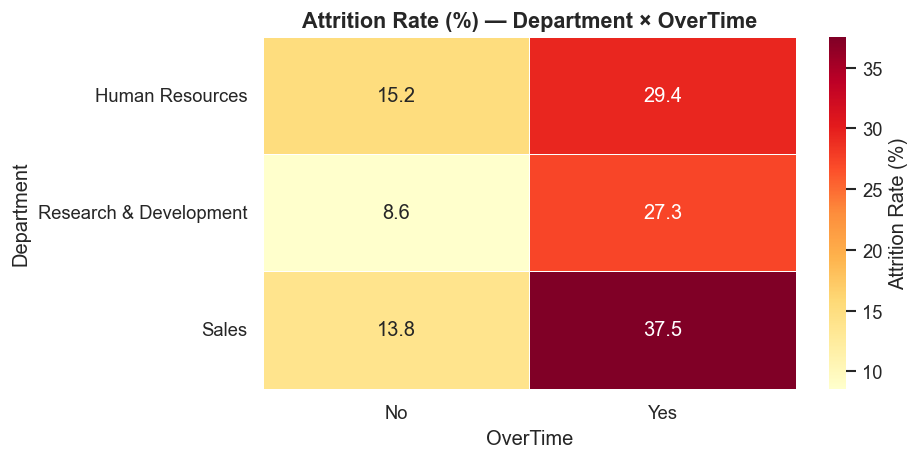

In [49]:
pivot = df_eda.groupby(['Department', 'OverTime'])['Attrition'].apply(
    lambda x: round((x == 'Yes').sum() / len(x) * 100, 1)
).unstack()

fig, ax = plt.subplots(figsize=(8, 4))
sns.heatmap(pivot, annot=True, fmt='.1f', cmap='YlOrRd', ax=ax,
            linewidths=0.5, cbar_kws={'label': 'Attrition Rate (%)'})
ax.set_title('Attrition Rate (%) — Department × OverTime', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../assets/plots/08_overtime_department_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

Overtime combined with department reveals that Sales employees working overtime
have the highest attrition rate of any group. Even within departments, overtime
consistently doubles or triples the attrition rate — making it the single most
actionable insight for HR intervention.

### Key Business Insights Summary

In [18]:
insights = {
    "Overall attrition rate": f"{(df_eda['Attrition']=='Yes').mean()*100:.1f}%",
    "Highest attrition job role": df_eda.groupby('JobRole')['Attrition'].apply(lambda x: (x=='Yes').mean()).idxmax(),
    "OverTime attrition rate": f"{(df_eda[df_eda['OverTime']=='Yes']['Attrition']=='Yes').mean()*100:.1f}%",
    "Non-overtime attrition rate": f"{(df_eda[df_eda['OverTime']=='No']['Attrition']=='Yes').mean()*100:.1f}%",
    "Highest attrition marital status": df_eda.groupby('MaritalStatus')['Attrition'].apply(lambda x: (x=='Yes').mean()).idxmax(),
    "Avg age (attrition=Yes)": f"{df_eda[df_eda['Attrition']=='Yes']['Age'].mean():.1f}",
    "Avg age (attrition=No)": f"{df_eda[df_eda['Attrition']=='No']['Age'].mean():.1f}",
    "Avg income (attrition=Yes)": f"${df_eda[df_eda['Attrition']=='Yes']['MonthlyIncome'].mean():,.0f}",
    "Avg income (attrition=No)": f"${df_eda[df_eda['Attrition']=='No']['MonthlyIncome'].mean():,.0f}",
}

print("=" * 45)
print("       KEY BUSINESS INSIGHTS")
print("=" * 45)
for k, v in insights.items():
    print(f"  {k:<38} {v}")
print("=" * 45)

       KEY BUSINESS INSIGHTS
  Overall attrition rate                 16.1%
  Highest attrition job role             Sales Representative
  OverTime attrition rate                30.5%
  Non-overtime attrition rate            10.4%
  Highest attrition marital status       Single
  Avg age (attrition=Yes)                33.6
  Avg age (attrition=No)                 37.6
  Avg income (attrition=Yes)             $4,787
  Avg income (attrition=No)              $6,833


Summary of actionable findings for HR:
- Target retention efforts at young, low-income, overtime employees first
- Sales Representatives need the most urgent attention
- Improving WorkLifeBalance and JobSatisfaction scores could significantly
  reduce attrition
- Stock options and career progression (JobLevel) are strong retention tools
- Frequent business travel policy should be reviewed given its attrition impact

# Feature Preprocessing and Transformation

In [19]:
''' Here's a description of each column in your DataFrame df:

Numerical Features:

Age: The age of the employee.
DailyRate: The daily rate of pay for the employee.
DistanceFromHome: The distance in miles from the employee's home to work.
Education: The level of education, typically represented as a scale (e.g., 1='Below College', 2='College', 3='Bachelor', 4='Master', 5='Doctor').
EmployeeCount: A constant value (usually 1) for each employee, often used for counting or aggregation.
EmployeeNumber: A unique identifier for each employee.
EnvironmentSatisfaction: The employee's satisfaction level with their work environment (e.g., 1='Low', 2='Medium', 3='High', 4='Very High').
HourlyRate: The hourly rate of pay for the employee.
JobInvolvement: The level of involvement and commitment the employee shows towards their job (e.g., 1='Low', 2='Medium', 3='High', 4='Very High').
JobLevel: The job level or seniority of the employee within the company (e.g., 1='Entry', 2='Junior', 3='Senior', 4='Manager', 5='Director').
JobSatisfaction: The employee's satisfaction level with their job (e.g., 1='Low', 2='Medium', 3='High', 4='Very High').
MonthlyIncome: The employee's monthly income.
MonthlyRate: The employee's monthly rate of pay.
NumCompaniesWorked: The total number of companies the employee has worked for before this one.
PercentSalaryHike: The percentage increase in the employee's salary in the last year.
PerformanceRating: The employee's last performance rating (e.g., 1='Low', 2='Good', 3='Excellent', 4='Outstanding').
RelationshipSatisfaction: The employee's satisfaction with their relationships at work (e.g., 1='Low', 2='Medium', 3='High', 4='Very High').
StandardHours: Standard working hours (appears to be a constant 80 in this dataset).
StockOptionLevel: The stock option level granted to the employee (e.g., 0, 1, 2, 3).
TotalWorkingYears: The total number of years the employee has worked throughout their career.
TrainingTimesLastYear: The number of times the employee participated in training sessions last year.
WorkLifeBalance: The employee's perception of their work-life balance (e.g., 1='Bad', 2='Good', 3='Better', 4='Best').
YearsAtCompany: The total number of years the employee has been with the current company.
YearsInCurrentRole: The number of years the employee has been in their current role.
YearsSinceLastPromotion: The number of years that have passed since the employee's last promotion.
YearsWithCurrManager: The number of years the employee has been working with their current manager.
Categorical Features:

Attrition: Indicates whether the employee has left the company ('Yes') or is still employed ('No'). This is often the target variable in HR analytics.
BusinessTravel: Describes the frequency of business travel required for the employee's role (e.g., 'Travel_Rarely', 'Travel_Frequently', 'Non-Travel').
Department: The department to which the employee belongs (e.g., 'Sales', 'Research & Development', 'Human Resources').
EducationField: The primary field of study for the employee's education (e.g., 'Life Sciences', 'Medical', 'Marketing', 'Technical Degree', 'Human Resources', 'Other').
Gender: The gender of the employee ('Female' or 'Male').
JobRole: The specific job role or position held by the employee (e.g., 'Sales Executive', 'Research Scientist', 'Laboratory Technician').
MaritalStatus: The marital status of the employee ('Single', 'Married', 'Divorced').
Over18: Indicates if the employee is over 18 years old (always 'Y' in this dataset).
OverTime: Indicates whether the employee works overtime ('Yes') or not ('No').

'''

" Here's a description of each column in your DataFrame df:\n\nNumerical Features:\n\nAge: The age of the employee.\nDailyRate: The daily rate of pay for the employee.\nDistanceFromHome: The distance in miles from the employee's home to work.\nEducation: The level of education, typically represented as a scale (e.g., 1='Below College', 2='College', 3='Bachelor', 4='Master', 5='Doctor').\nEmployeeCount: A constant value (usually 1) for each employee, often used for counting or aggregation.\nEmployeeNumber: A unique identifier for each employee.\nEnvironmentSatisfaction: The employee's satisfaction level with their work environment (e.g., 1='Low', 2='Medium', 3='High', 4='Very High').\nHourlyRate: The hourly rate of pay for the employee.\nJobInvolvement: The level of involvement and commitment the employee shows towards their job (e.g., 1='Low', 2='Medium', 3='High', 4='Very High').\nJobLevel: The job level or seniority of the employee within the company (e.g., 1='Entry', 2='Junior', 3='

In [20]:
numerical_ordinal = [
    'Education', 'EnvironmentSatisfaction', 'JobInvolvement',
    'JobLevel', 'JobSatisfaction', 'PerformanceRating',
    'RelationshipSatisfaction', 'StockOptionLevel', 'WorkLifeBalance'
]  # 9

numerical_continuous = [
    'Age', 'DailyRate', 'DistanceFromHome', 'HourlyRate',
    'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked',
    'PercentSalaryHike', 'TotalWorkingYears', 'TrainingTimesLastYear',
    'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion',
    'YearsWithCurrManager'
]  # 14

categorical_ordinal = [
    'BusinessTravel'    # Non-Travel < Travel_Rarely < Travel_Frequently
]  # 1

categorical_nominal = [
    'Department', 'EducationField', 'Gender',
    'JobRole', 'MaritalStatus', 'OverTime'
]  # 6

label = ['Attrition']  # 1

columns_to_drop = [
    'EmployeeCount',   # constant = 1 for all rows
    'EmployeeNumber',  # just a row ID
    'Over18',          # constant = 'Y' for all rows
    'StandardHours'    # constant = 80 for all rows
]  # 4

# Verify: 9 + 14 + 1 + 6 + 1 + 4 = 35 ✓

In [21]:
print(f'total cols in input csv:{len(df.columns)}')
print(f'{len(numerical_ordinal) + len(numerical_continuous) + len(categorical_ordinal)+ len(categorical_nominal) + len(label) + len(columns_to_drop)}')

total cols in input csv:35
35


In [22]:
skewed_numerical_continuous = []
normal_numerical_continuous = []
for col in numerical_continuous:
  skewness = np.round(df[col].skew(), 2)
  if abs(skewness) > 0.5:
    skewed_numerical_continuous.append(col)
  else:
    normal_numerical_continuous.append(col)

In [23]:
len(numerical_continuous), len(skewed_numerical_continuous), len(normal_numerical_continuous)

(14, 10, 4)

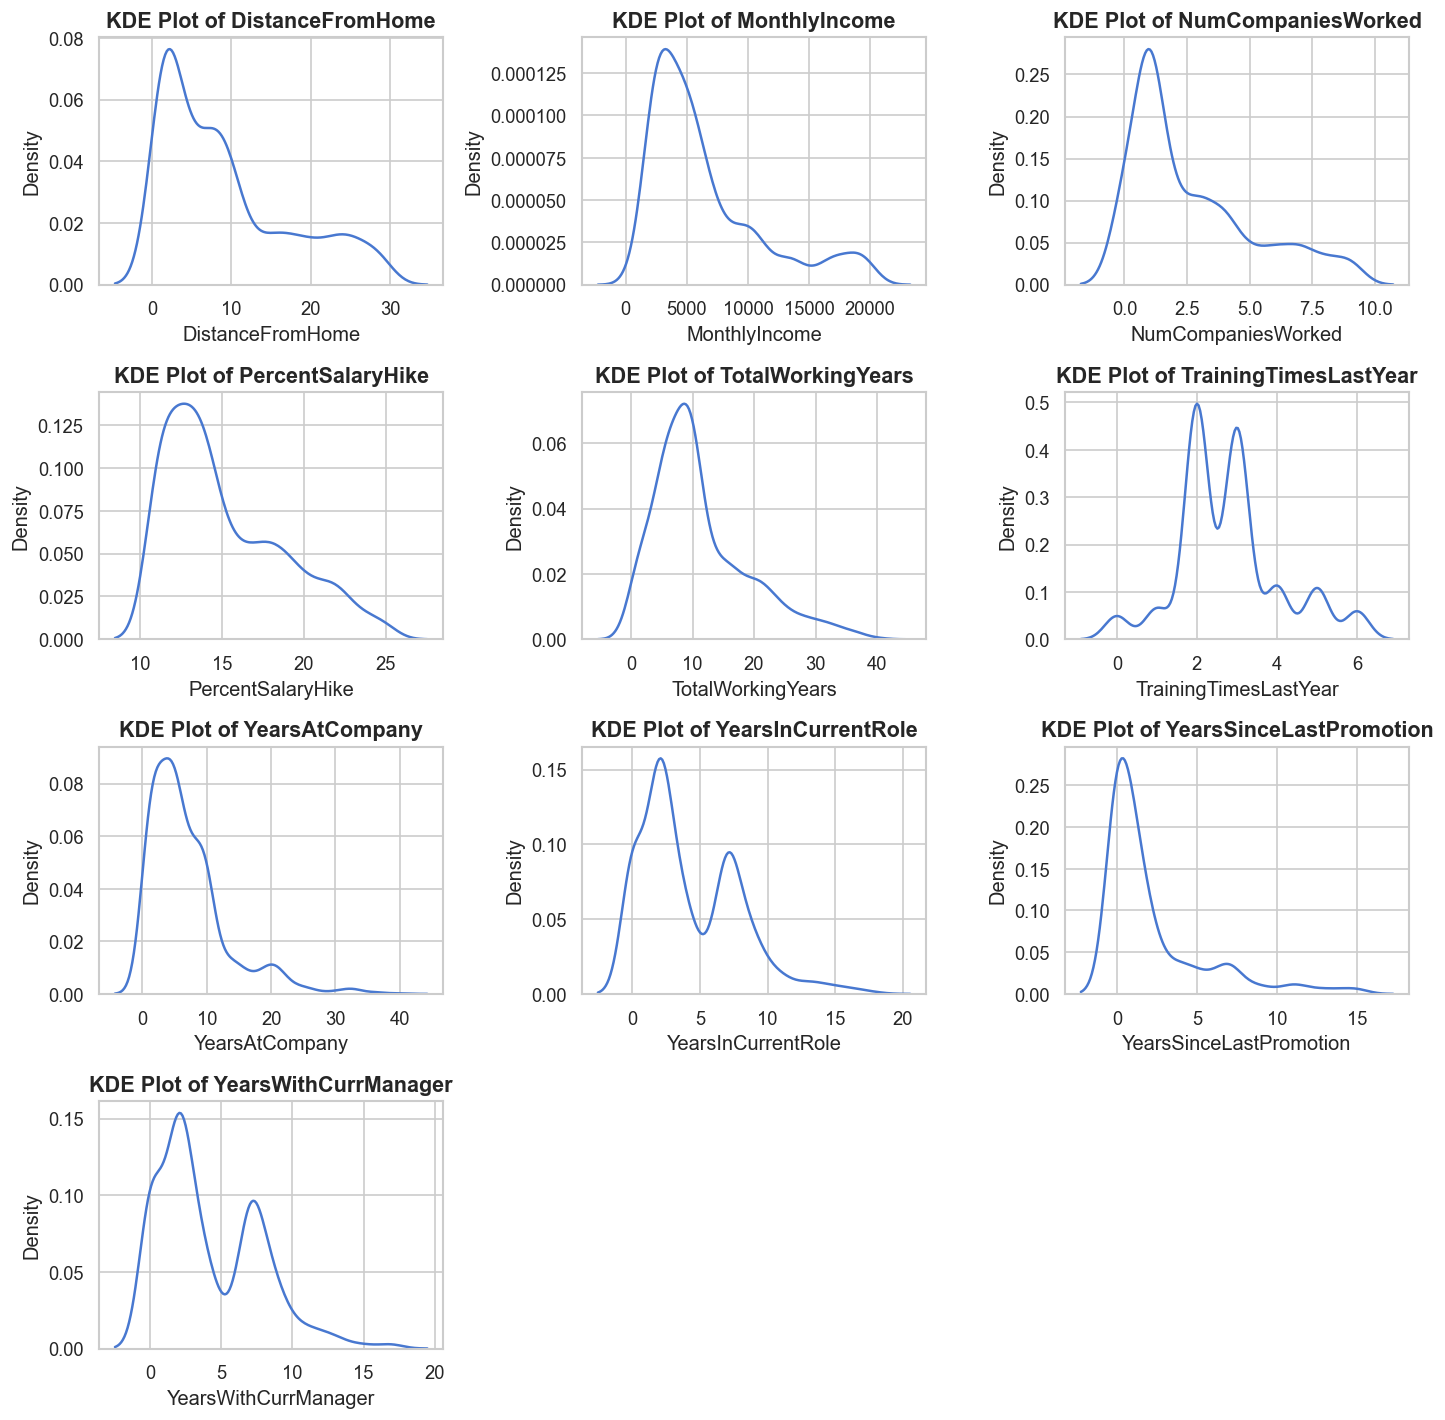

In [24]:
import math

n_cols = 3  # Number of columns in the subplot grid
n_plots = len(skewed_numerical_continuous)
n_rows = math.ceil(n_plots / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols * 4, n_rows * 3))
axes = axes.flatten() # Flatten the 2D array of axes for easy iteration

for i, col in enumerate(skewed_numerical_continuous):
    sns.kdeplot(df[col], ax=axes[i])
    axes[i].set_title(f'KDE Plot of {col}')

# Remove any unused subplots
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

In [25]:
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder, PowerTransformer, OrdinalEncoder, LabelEncoder
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from xgboost import XGBClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, classification_report

In [26]:
df = df.drop(columns=columns_to_drop, axis=1, errors='ignore')

In [27]:
len(df.columns)

31

In [28]:
le = LabelEncoder()
df['Attrition'] = le.fit_transform(df['Attrition'])

In [29]:
X_train, X_test, y_train, y_test = train_test_split(df.drop(columns=['Attrition']), df['Attrition'], test_size=0.3, random_state=42)

In [30]:
transformer = ColumnTransformer(transformers=[
    ('yeo-johnson', PowerTransformer(method='yeo-johnson', standardize= True), skewed_numerical_continuous),
    ('standardize', StandardScaler(), normal_numerical_continuous + numerical_ordinal),
    ('one-hot', OneHotEncoder(drop='first'), categorical_nominal),
    ('ordinal', Pipeline([
        ('encode', OrdinalEncoder(categories=[['Non-Travel','Travel_Rarely','Travel_Frequently']])),
        ('scale', StandardScaler())
    ]), categorical_ordinal)
], remainder='passthrough')

# Model Building and Eval

In [31]:
from imblearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE

In [32]:
fitted_models = {}

models = [LogisticRegression(random_state=42, class_weight='balanced', max_iter=1000),
          DecisionTreeClassifier(random_state=42, class_weight='balanced'),
          RandomForestClassifier(random_state=42, class_weight='balanced'),
          GradientBoostingClassifier(random_state=42),  # no class_weight support
          XGBClassifier(random_state=42, scale_pos_weight=6),  # 380/61 ≈ 6
          SVC(class_weight='balanced', probability=True),
          KNeighborsClassifier(),]

for model in models:

    pipe = Pipeline(steps=[
    ('transformer', transformer),
    ('smote', SMOTE(random_state=42)),
    ('model', model)
])
    pipe.fit(X_train, y_train)
    fitted_models[model.__class__.__name__] = pipe
    y_pred = pipe.predict(X_test)
    print('<----------------------------------------------------------------------------------->')
    print(f'Model: {model.__class__.__name__}')
    print(f'report: {classification_report(y_test, y_pred)}')

D:\Anaconda\envs\employee-attrition-prediction\Lib\site-packages\joblib\externals\loky\backend\context.py:136: UserWarning: Could not find the number of physical cores for the following reason:
[WinError 2] The system cannot find the file specified
Returning the number of logical cores instead. You can silence this warning by setting LOKY_MAX_CPU_COUNT to the number of cores you want to use.
  warnings.warn(
  File "D:\Anaconda\envs\employee-attrition-prediction\Lib\site-packages\joblib\externals\loky\backend\context.py", line 257, in _count_physical_cores
    cpu_info = subprocess.run(
               ^^^^^^^^^^^^^^^
  File "D:\Anaconda\envs\employee-attrition-prediction\Lib\subprocess.py", line 548, in run
    with Popen(*popenargs, **kwargs) as process:
         ^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "D:\Anaconda\envs\employee-attrition-prediction\Lib\subprocess.py", line 1026, in __init__
    self._execute_child(args, executable, preexec_fn, close_fds,
  File "D:\Anaconda\envs\employee-

<----------------------------------------------------------------------------------->
Model: LogisticRegression
report:               precision    recall  f1-score   support

           0       0.93      0.80      0.86       380
           1       0.33      0.61      0.43        61

    accuracy                           0.78       441
   macro avg       0.63      0.70      0.64       441
weighted avg       0.84      0.78      0.80       441

<----------------------------------------------------------------------------------->
Model: DecisionTreeClassifier
report:               precision    recall  f1-score   support

           0       0.88      0.89      0.89       380
           1       0.28      0.28      0.28        61

    accuracy                           0.80       441
   macro avg       0.58      0.58      0.58       441
weighted avg       0.80      0.80      0.80       441

<----------------------------------------------------------------------------------->
Model: RandomFor

# Hyperparameter Tuning

In [33]:
from sklearn.model_selection import RandomizedSearchCV

param_dist = {
    'model__n_estimators': [100, 200, 300, 400, 500],
    'model__learning_rate': [0.01, 0.05, 0.1, 0.2],
    'model__max_depth': [3, 4, 5, 6, 7],
    'model__min_samples_split': [2, 5, 10, 15],
    'model__subsample': [0.6, 0.7, 0.8, 0.9, 1.0],
    'model__min_samples_leaf': [1, 2, 4]
}

pipe_gb = Pipeline(steps=[
    ('transformer', transformer),
    ('smote', SMOTE(random_state=42)),
    ('model', GradientBoostingClassifier(random_state=42))
])

random_search = RandomizedSearchCV(
    estimator=pipe_gb,
    param_distributions=param_dist,
    n_iter=50,
    scoring='f1',
    cv=5,
    random_state=42,
    n_jobs=-1,
    verbose=2
)

random_search.fit(X_train, y_train)

print(f'Best params: {random_search.best_params_}')
print(f'Best CV F1: {random_search.best_score_:.3f}')

y_pred = random_search.predict(X_test)
print(classification_report(y_test, y_pred))

Fitting 5 folds for each of 50 candidates, totalling 250 fits
Best params: {'model__subsample': 0.6, 'model__n_estimators': 300, 'model__min_samples_split': 15, 'model__min_samples_leaf': 2, 'model__max_depth': 3, 'model__learning_rate': 0.05}
Best CV F1: 0.524
              precision    recall  f1-score   support

           0       0.91      0.97      0.94       380
           1       0.67      0.43      0.52        61

    accuracy                           0.89       441
   macro avg       0.79      0.70      0.73       441
weighted avg       0.88      0.89      0.88       441



# SHAP

### SHAP Analysis — Model Interpretability

SHAP (SHapley Additive exPlanations) explains the output of our model by
assigning each feature a contribution value for each prediction. Unlike
feature importance from the model itself, SHAP values are theoretically
grounded and show both the magnitude and direction of each feature's impact.

We first extract the best pipeline from RandomizedSearchCV and transform
the data using only the preprocessing steps (excluding SMOTE and the model)
to get the final feature matrix that the model actually sees.

In [35]:
import shap

# get the best pipeline from random search
best_pipe = random_search.best_estimator_

# transform X_train using the pipeline's transformer step only
X_train_transformed = best_pipe.named_steps['transformer'].transform(X_train)
X_test_transformed = best_pipe.named_steps['transformer'].transform(X_test)

# get feature names after column transformer
feature_names = best_pipe.named_steps['transformer'].get_feature_names_out().tolist()

# create SHAP explainer
explainer = shap.TreeExplainer(best_pipe.named_steps['model'])
shap_values = explainer.shap_values(X_test_transformed)

### Global Feature Importance

This bar plot shows the average absolute SHAP value for each feature across
all test samples — i.e. which features matter most to the model overall.
Longer bars = more important features regardless of direction.

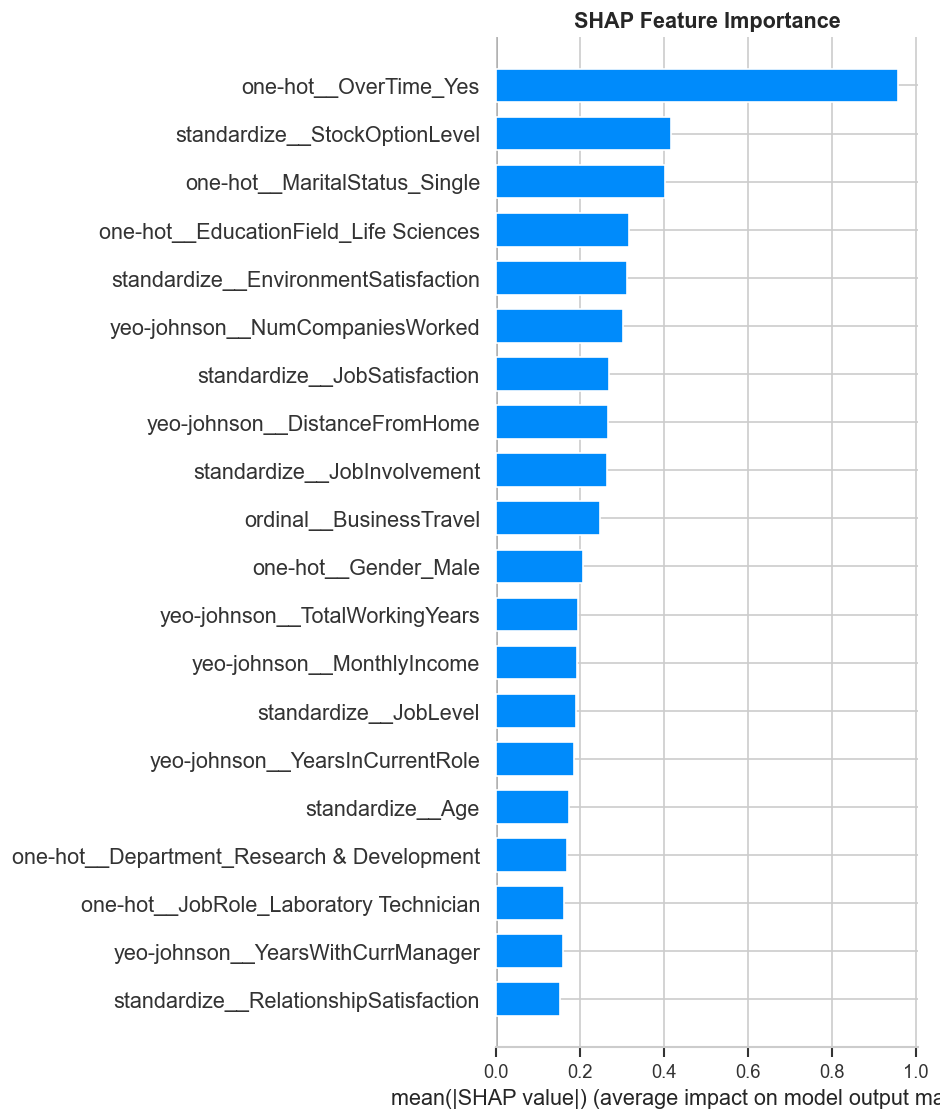

In [50]:
# Global feature importance — Bar plot
plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values, X_test_transformed,
                  feature_names=feature_names,
                  plot_type='bar', show=False)
plt.title('SHAP Feature Importance', fontweight='bold')
plt.tight_layout()
plt.savefig('../assets/plots/09_shap_bar.png', dpi=150, bbox_inches='tight')
plt.show()



Across all employees in the test set, the top drivers of attrition are:
- OverTime is by far the most important feature, nearly 2x more impactful
  than the second most important feature
- StockOptionLevel and MaritalStatus_Single are the next strongest predictors
- EnvironmentSatisfaction, JobSatisfaction and JobInvolvement all rank highly,
  confirming that employee engagement drives retention more than compensation alone
- Demographic features like Age and Gender are among the least important

This confirms our EDA findings and validates the model's learned patterns.

### SHAP Beeswarm Plot — Feature Impact Direction

The beeswarm plot goes one step further than the bar plot. Each dot is one
employee from the test set. The color shows the feature value (red = high,
blue = low) and the x-axis shows whether that value pushed the prediction
toward attrition (positive) or away from it (negative).

This is the most information-dense SHAP plot and the best one to show
in interviews or to business stakeholders.

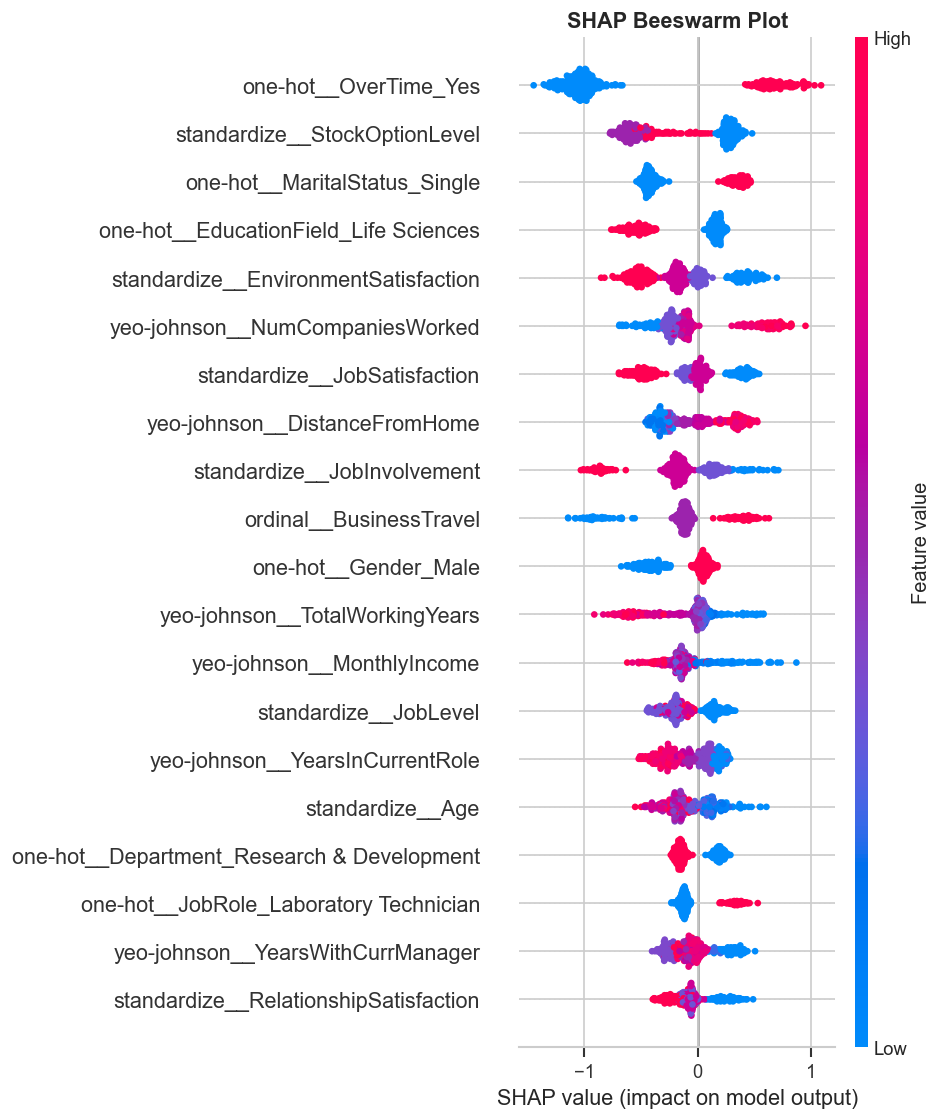

In [51]:
# Beeswarm plot — shows direction of impact too
plt.figure(figsize=(10, 8))
shap.summary_plot(shap_values, X_test_transformed,
                  feature_names=feature_names, show=False)
plt.title('SHAP Beeswarm Plot', fontweight='bold')
plt.tight_layout()
plt.savefig('../assets/plots/10_shap_beeswarm.png', dpi=150, bbox_inches='tight')
plt.show()



The beeswarm plot reveals both importance and direction of each feature:
- OverTime=Yes (red/high) strongly pushes predictions toward attrition,
  while OverTime=No (blue) pushes away — the clearest signal in the dataset
- Low StockOptionLevel (blue) increases attrition risk — equity compensation
  is a strong retention tool
- MaritalStatus=Single (red/high=1) increases attrition probability —
  single employees have less financial anchoring
- Low EnvironmentSatisfaction and JobSatisfaction (blue) both push toward
  attrition — dissatisfied employees leave
- High NumCompaniesWorked (red) increases attrition risk — job-hoppers
  are more likely to leave again
- High DistanceFromHome (red) moderately increases attrition risk
- Low MonthlyIncome (blue on yeo-johnson__MonthlyIncome) increases
  attrition — underpaid employees leave more

Overall the model has learned interpretable, business-logical patterns
which increases our confidence in its predictions.

### Local Explanation — Why Will This Employee Leave?

While the previous plots explain the model globally, this waterfall plot
explains a single prediction. It shows exactly which features pushed the
model toward predicting attrition=Yes for one specific employee, and by
how much. This is the kind of insight HR teams can actually act on —
identifying the specific reasons behind an individual's attrition risk.

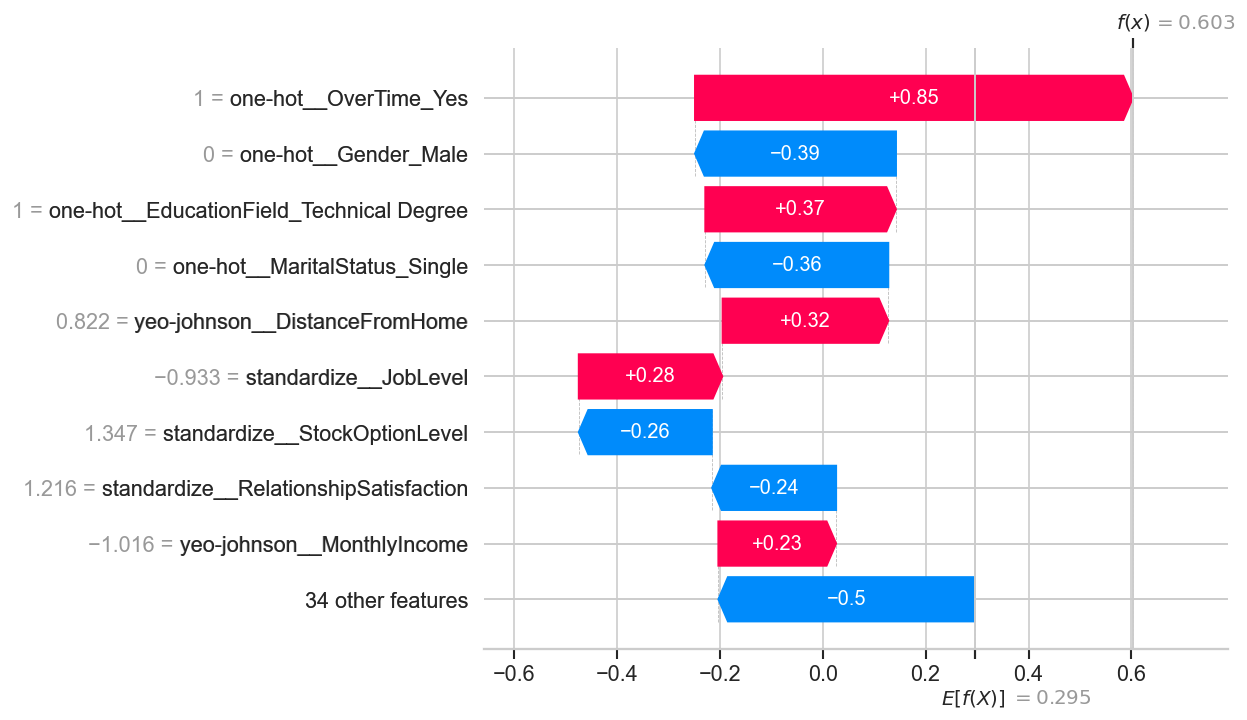

In [38]:
# Local explanation — why did the model predict attrition for one specific employee
# pick index 0 or any employee predicted as 1
idx = np.where(best_pipe.predict(X_test) == 1)[0][0]

shap.waterfall_plot(shap.Explanation(
    values=shap_values[idx],
    base_values=explainer.expected_value,
    data=X_test_transformed[idx],
    feature_names=feature_names
))


For this specific employee, the model predicted attrition probability of 0.603
(above the base rate of 0.295). Key drivers pushing toward attrition:
- OverTime=Yes was the single biggest factor (+0.85)
- EducationField=Technical Degree pushed toward attrition (+0.37)
- DistanceFromHome being high contributed positively (+0.32)

Factors pushing against attrition for this employee:
- Being Male reduced attrition probability (-0.39)
- MaritalStatus=Single being absent reduced risk (-0.36)
- High StockOptionLevel acted as a retention factor (-0.26)

This kind of individual explanation is what makes the model actionable
for HR — instead of just "this person will leave", we now know exactly why.

# ROC-AUC Curve


### ROC-AUC Curve — Model Comparison

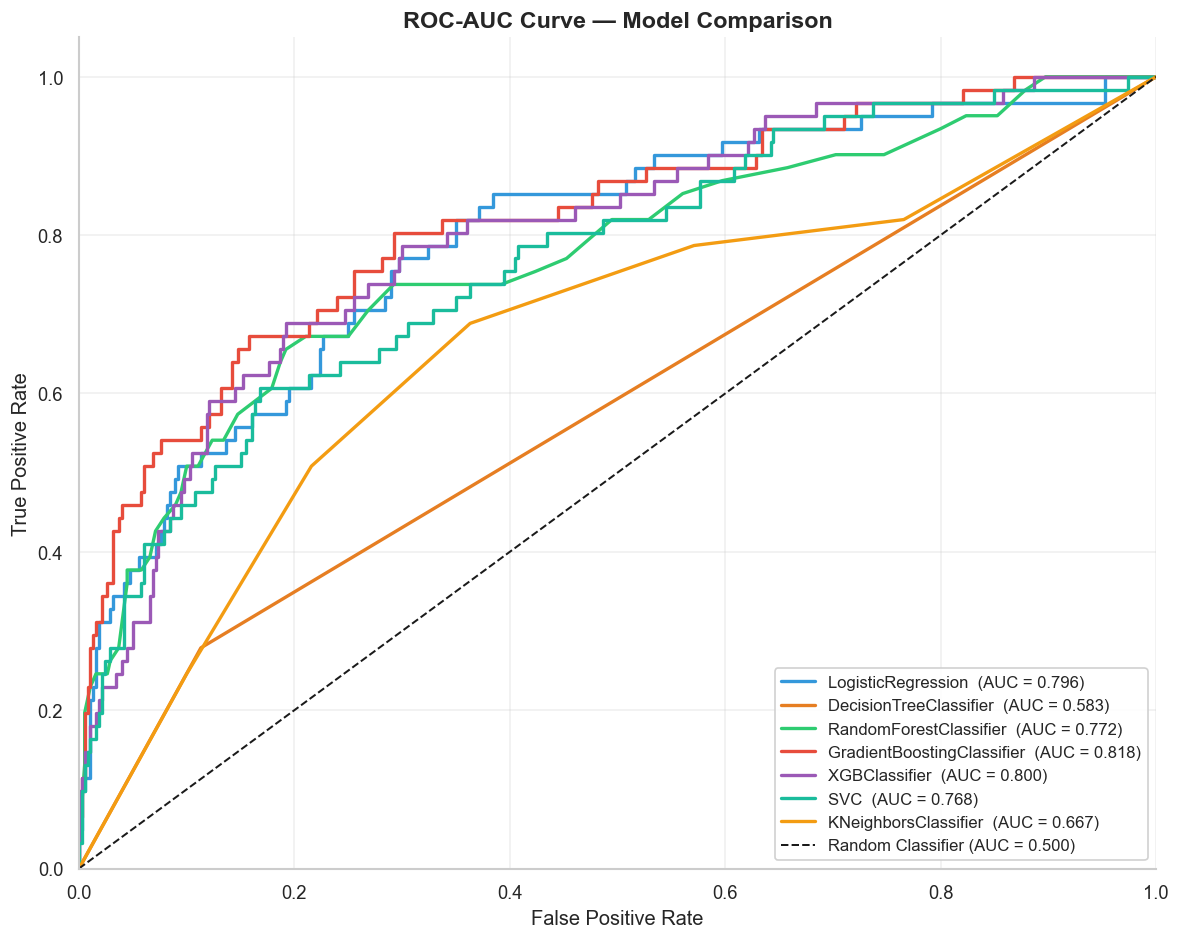

In [52]:
from sklearn.metrics import roc_curve, auc

colors = ['#3498db', '#e67e22', '#2ecc71', '#e74c3c', '#9b59b6', '#1abc9c', '#f39c12']
fitted_models['GradientBoostingClassifier'] = random_search.best_estimator_

fig, ax = plt.subplots(figsize=(10, 8))

for (name, pipe), color in zip(fitted_models.items(), colors):
    y_prob = pipe.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    roc_auc = auc(fpr, tpr)
    ax.plot(fpr, tpr, color=color, linewidth=2,
            label=f'{name}  (AUC = {roc_auc:.3f})')

ax.plot([0, 1], [0, 1], 'k--', linewidth=1.2, label='Random Classifier (AUC = 0.500)')
ax.set_xlim([0.0, 1.0])
ax.set_ylim([0.0, 1.05])
ax.set_xlabel('False Positive Rate', fontsize=12)
ax.set_ylabel('True Positive Rate', fontsize=12)
ax.set_title('ROC-AUC Curve — Model Comparison', fontsize=14, fontweight='bold')
ax.legend(loc='lower right', fontsize=10, framealpha=0.9)
ax.grid(True, alpha=0.3)
sns.despine()
plt.tight_layout()
plt.savefig('../assets/plots/11_roc_auc.png', dpi=150, bbox_inches='tight')
plt.show()



AUC measures how well the model distinguishes between attrition and non-attrition
regardless of threshold. An AUC of 1.0 is perfect, 0.5 is random (dashed line).

Key observations:
- GradientBoosting (Tuned) has the highest AUC of 0.818 — confirming it as
  the best model for this dataset
- XGBoost is close behind at 0.800, showing ensemble methods dominate here
- LogisticRegression performs surprisingly well at 0.796 despite being the
  simplest model — suggesting the relationships in this data are partly linear
- RandomForest at 0.772 underperforms relative to expectations, likely due
  to overfitting on the majority class
- DecisionTree has the worst AUC at 0.583, barely better than random —
  single trees are too unstable for this dataset
- All models significantly outperform the random classifier baseline

# Confusion Matrix

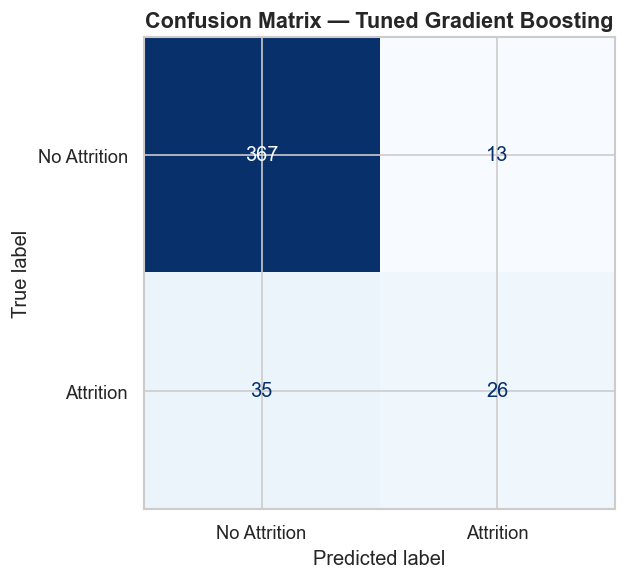

In [53]:
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix

fig, ax = plt.subplots(figsize=(6, 5))

cm = confusion_matrix(y_test, random_search.best_estimator_.predict(X_test))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No Attrition', 'Attrition'])
disp.plot(ax=ax, colorbar=False, cmap='Blues')

ax.set_title('Confusion Matrix — Tuned Gradient Boosting', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../assets/plots/12_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()



Out of 441 test employees:
- 367 correctly predicted as No Attrition (True Negatives)
- 26 correctly predicted as Attrition (True Positives)
- 35 missed attrition cases (False Negatives) — employees who left but
  model predicted they would stay. Most costly mistake in HR context.
- 13 false alarms (False Positives) — employees predicted to leave but stayed

The model is conservative — it misses more attrition cases than it
false-alarms. In a real HR setting, reducing False Negatives (35) should
be the priority since failing to identify an employee who will leave is
more costly than an unnecessary retention intervention.

# Saving the best model

In [41]:
import joblib

joblib.dump(random_search.best_estimator_, 'attrition_model.pkl')
print("Model saved successfully")

Model saved successfully
